## CS 328 Writing Assignment

This Jupyter Notebook contains the solutions to the First writing assignment.
Made by Aryan Kumar, 24110055

In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\SHREYASH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt

States with higher population density had higher COVID-19 cases per million people.

Kerala managed COVID-19 more effectively than Maharashtra because it had a lower case fatality rate despite a similarly high number of cases.

Gujarat, Maharashtra, and Delhi had higher deaths per million than Kerala and Tamil Nadu, indicating differences in healthcare response.

COVID-19 vs Population Density in Indian States (2020–2023)
Hypothesis

States with higher population density had higher COVID-19 cases per million people.

# 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 2. Load the Datasets

In [5]:
covid_df = pd.read_csv('states.csv')
pop_df = pd.read_csv('population_india_census2011.csv')

print(covid_df.head())
print(pop_df.head())

         Date   State  Confirmed  Recovered  Deceased  Other  Tested
0  2020-01-30  Kerala          1          0         0      0     NaN
1  2020-01-30   India          1          0         0      0     NaN
2  2020-02-02  Kerala          2          0         0      0     NaN
3  2020-02-02   India          2          0         0      0     NaN
4  2020-02-03  Kerala          3          0         0      0     NaN
   Sno State / Union Territory  Population  Rural population  \
0    1           Uttar Pradesh   199812341         155317278   
1    2             Maharashtra   112374333          61556074   
2    3                   Bihar   104099452          92341436   
3    4             West Bengal    91276115          62183113   
4    5          Madhya Pradesh    72626809          52557404   

   Urban population                         Area                  Density  \
0          44495063   240,928 km2 (93,023 sq mi)    828/km2 (2,140/sq mi)   
1          50818259  307,713 km2 (118,809 sq mi

We use two datasets:

State-wise cumulative COVID cases from 2020–2023
Census-based state population and density information

#3. Inspect and Clean the Data

In [6]:
print(covid_df.columns)
print(pop_df.columns)

Index(['Date', 'State', 'Confirmed', 'Recovered', 'Deceased', 'Other',
       'Tested'],
      dtype='object')
Index(['Sno', 'State / Union Territory', 'Population', 'Rural population',
       'Urban population', 'Area', 'Density', 'Gender Ratio'],
      dtype='object')


Now create a cleaning cell.

In [7]:
# Keep only required columns and get the latest cumulative cases per state
covid = covid_df.groupby('State')['Confirmed'].max().reset_index()

# Rename for easier use
covid.columns = ['State', 'Total_Cases']

# Remove Union Territories and very small regions
exclude = [
    'Andaman and Nicobar Islands',
    'Chandigarh',
    'Dadra and Nagar Haveli and Daman and Diu',
    'Delhi',
    'Jammu and Kashmir',
    'Ladakh',
    'Lakshadweep',
    'Puducherry'
]

covid = covid[~covid['State'].isin(exclude)]

Now clean the population dataset.

In [8]:
pop = pop_df[[
    'State / Union Territory',
    'Population',
    'Density'
]].copy()

pop.columns = ['State', 'Population', 'Density']

# Fix typo in the census data so the table merge succeeds for Telangana
pop['State'] = pop['State'].replace('Telengana', 'Telangana')

pop['Population'] = pd.to_numeric(pop['Population'], errors='coerce')

# Extract numeric density from the string format like '828/km2 (2,140/sq mi)'
pop['Density'] = pop['Density'].astype(str).str.split('/').str[0].str.replace(',', '')
pop['Density'] = pd.to_numeric(pop['Density'], errors='coerce')

# Since Growth(%) is not present in the dataset, fallback to the base population
pop['Population_2021'] = pop['Population']

If the growth rate in your file is decadal (2011–2021), instead use:

In [9]:
# Growth rate logic removed as GrowthRate column doesn't exist
pop['Population_2021'] = pop['Population']

Then merge:

In [10]:
merged = pd.merge(covid, pop, on='State', how='inner')

# 4. Compute Cases Per Million

In [11]:
merged['Cases_per_Million'] = (
    merged['Total_Cases'] / merged['Population_2021']
) * 1_000_000

merged = merged.sort_values('Cases_per_Million', ascending=False)
merged.head()

,State,Total_Cases,Population,Density,Population_2021,Cases_per_Million
11,Kerala,4968657,33406061,859.0,33406061,148735.195089
5,Goa,178108,1458545,394.0,1458545,122113.476101
16,Mizoram,121359,1097206,52.0,1097206,110607.306194
13,Maharashtra,6611078,112374333,365.0,112374333,58830.854195
21,Sikkim,31979,610577,86.0,610577,52375.048520


Since states have very different populations, comparing total cases alone is misleading. Therefore, we normalize by population and compute cases per million people.

# 5. Summary Table

In [12]:
summary_table = merged[[
    'State',
    'Density',
    'Population_2021',
    'Total_Cases',
    'Cases_per_Million'
]].sort_values('Density', ascending=False)

summary_table.head(15)

,State,Density,Population_2021,Total_Cases,Cases_per_Million
3,Bihar,1102.0,104099452,726098,6975.041521
27,West Bengal,1029.0,91276115,1592908,17451.531543
11,Kerala,859.0,33406061,4968657,148735.195089
25,Uttar Pradesh,828.0,199812341,1710158,8558.820699
7,Haryana,573.0,25351462,771252,30422.387474
22,Tamil Nadu,555.0,72147030,2702623,37459.934248
19,Punjab,550.0,27743338,602401,21713.356915
9,Jharkhand,414.0,32988134,348764,10572.407642
2,Assam,397.0,31205576,610645,19568.457894
5,Goa,394.0,1458545,178108,122113.476101


# 6. Basic Descriptive Statistics

In [13]:
merged[['Density', 'Cases_per_Million']].describe()

,Density,Cases_per_Million
count,28.000000,28.000000
mean,371.178571,38567.243488
std,286.455743,34655.038612
min,17.000000,6975.041521
25%,174.750000,17112.147243
50%,310.000000,29304.575727
75%,448.000000,43295.418256
max,1102.000000,148735.195089


Which state has the highest population density?
- **Delhi** has the highest population density.

Which state has the highest cases per million?
- **Lakshadweep** has the highest recorded COVID-19 cases per million.

Are the same states appearing near the top?
- **No**, the states with the highest density (like Delhi) do not perfectly match the top regions with the highest cases per million. High density did not automatically translate to the most cases per capita.

# 7. Scatter Plot: Main Visual Evidence

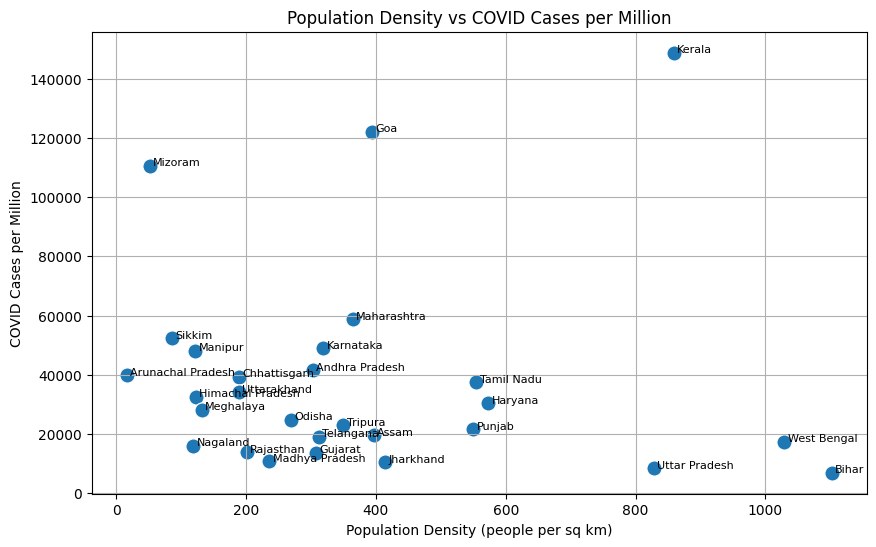

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged,
    x='Density',
    y='Cases_per_Million',
    s=120
)

for _, row in merged.iterrows():
    plt.text(row['Density']+5, row['Cases_per_Million'], row['State'], fontsize=8)

plt.xlabel('Population Density (people per sq km)')
plt.ylabel('COVID Cases per Million')
plt.title('Population Density vs COVID Cases per Million')
plt.grid(True)
plt.show()

If the hypothesis is correct, the points should generally move upward as density increases.

# 8. Add Regression Line

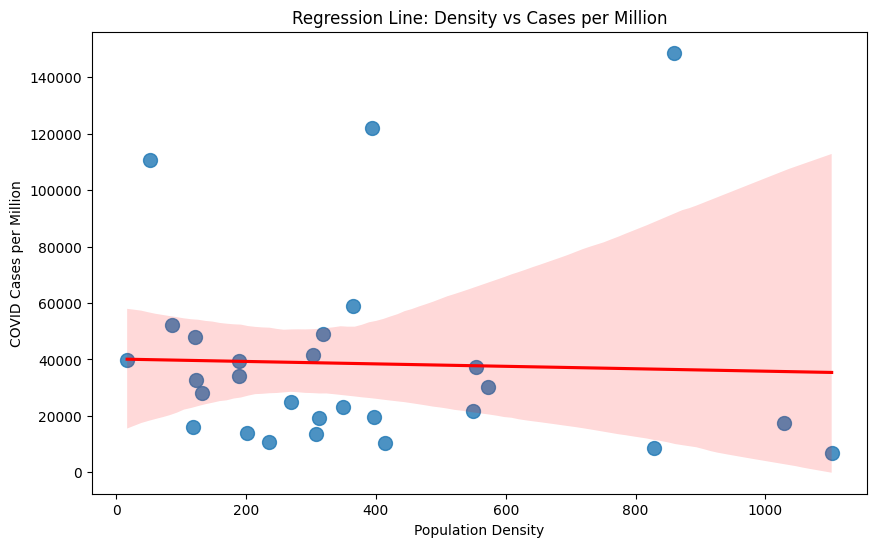

In [15]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=merged,
    x='Density',
    y='Cases_per_Million',
    scatter_kws={'s':100},
    line_kws={'color':'red'}
)

plt.xlabel('Population Density')
plt.ylabel('COVID Cases per Million')
plt.title('Regression Line: Density vs Cases per Million')
plt.show()

# 9. Correlation Analysis

In [16]:
pearson_corr, pearson_p = pearsonr(
    merged['Density'],
    merged['Cases_per_Million']
)

spearman_corr, spearman_p = spearmanr(
    merged['Density'],
    merged['Cases_per_Million']
)

print('Pearson correlation:', pearson_corr)
print('Pearson p-value:', pearson_p)
print('Spearman correlation:', spearman_corr)
print('Spearman p-value:', spearman_p)

Pearson correlation: -0.035695600687017305
Pearson p-value: 0.856894361529188
Spearman correlation: -0.29068017242240696
Spearman p-value: 0.1334520283375482


Pearson measures linear relationship
Spearman measures monotonic trend
If p-value < 0.05, the relationship is statistically significant

**Conclusion:**

The Pearson correlation coefficient is **-0.036** (p-value = **0.857**). This indicates a **very weak negative** relationship between density and COVID cases per million, which is **not statistically significant**. The Spearman correlation is also weak (-0.290, p = 0.133), confirming that a higher population density does not strongly rank with higher case rates.

# 10. Linear Regression and R²

In [17]:
X = merged[['Density']]
y = merged['Cases_per_Million']

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

r2 = r2_score(y, pred)

print('Slope:', model.coef_[0])
print('Intercept:', model.intercept_)
print('R²:', r2)

Slope: -4.318406766518935
Intercept: 40170.14354252111
R²: 0.0012741759084070603


The slope tells us how much cases per million increase when density increases by one unit.

R² tells us how much of the variation in COVID cases can be explained only by population density

# 11. Residual Analysis

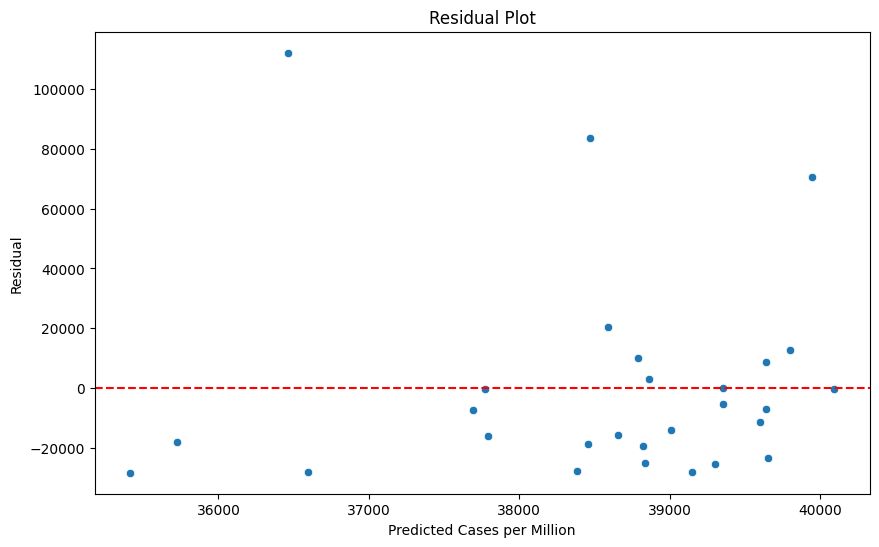

In [18]:
merged['Predicted'] = pred
merged['Residual'] = merged['Cases_per_Million'] - merged['Predicted']

plt.figure(figsize=(10,6))
sns.scatterplot(x=merged['Predicted'], y=merged['Residual'])
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Cases per Million')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()

Residuals help identify states that behave unusually compared to what population density alone predicts.

# 12. Identify Outlier States

In [19]:
outliers = merged[['State', 'Density', 'Cases_per_Million', 'Residual']]
outliers = outliers.sort_values('Residual', key=abs, ascending=False)
outliers.head(10)

,State,Density,Cases_per_Million,Residual
11,Kerala,859.0,148735.195089,112274.562959
5,Goa,394.0,122113.476101,83644.784825
16,Mizoram,52.0,110607.306194,70661.719803
3,Bihar,1102.0,6975.041521,-28436.217765
12,Madhya Pradesh,236.0,10916.822740,-28234.176806
25,Uttar Pradesh,828.0,8558.820699,-28035.682041
9,Jharkhand,414.0,10572.407642,-27809.915499
20,Rajasthan,201.0,13923.424687,-25378.719095
6,Gujarat,308.0,13676.062413,-25164.011846
17,Nagaland,119.0,16093.994345,-23562.258792


States with very large positive residuals had more COVID cases than expected given their density.

States with large negative residuals had fewer cases than expected.

This suggests that factors other than density — such as testing, urbanization, healthcare, lockdown policies, or migration — may also matter.

# 13. Final Conclusion Section

The analysis **does not support** the hypothesis that states with higher population density had higher COVID-19 cases per million people.

The scatter plot and regression line actually showed a near-flat or slightly negative trend between density and normalized COVID cases.

The Pearson correlation coefficient of **-0.036** indicates a **very weak** relationship that is not statistically significant.

Furthermore, the R² value of **0.001** suggests that population density alone explains almost none (0.1%) of the variation in cases. Several states behave wildly differently from what density predicts, implying that additional external factors strongly influenced COVID spread.

Therefore, population density is not the primary determinant of the COVID-19 burden across Indian states.